In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as k


In [3]:
#Import car dataset 

car = pd.read_csv("CarPrice_Assignment.csv")

car.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
#datatypes
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
#Summary Statistics
car.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
#Columns
car.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [7]:
#Drop CarID
car.drop('car_ID', axis=1, inplace=True)

In [8]:
#Split into categorical and numeric columns
cat_col = [
    'symboling',
    'CarName',
    'fueltype',
    'aspiration',
    'doornumber',
    'carbody',
    'drivewheel',
    'enginelocation',
    'enginetype',
    'cylindernumber',
    'fuelsystem'
]

num_col = [
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'boreratio',
    'stroke',
    'compressionratio',
    'horsepower',
    'peakrpm',
    'citympg',
    'highwaympg',
    'price'
]


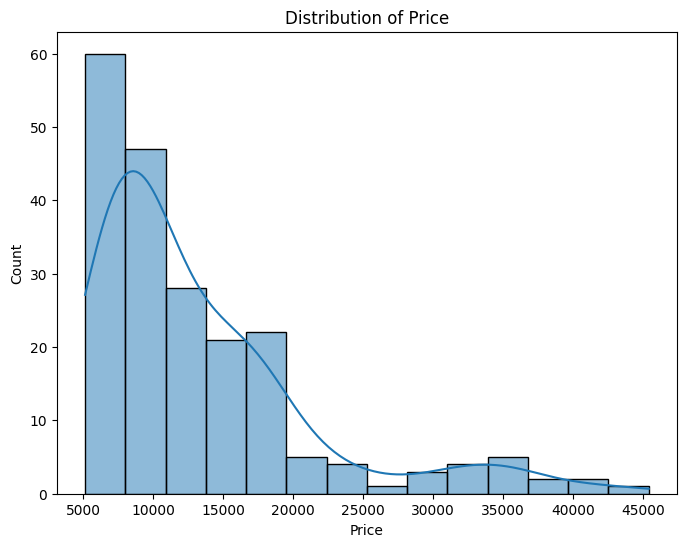

In [9]:
#Price Distribution
plt.figure(figsize = (8,6))
sns.histplot(x = car["price"], kde = True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.show()

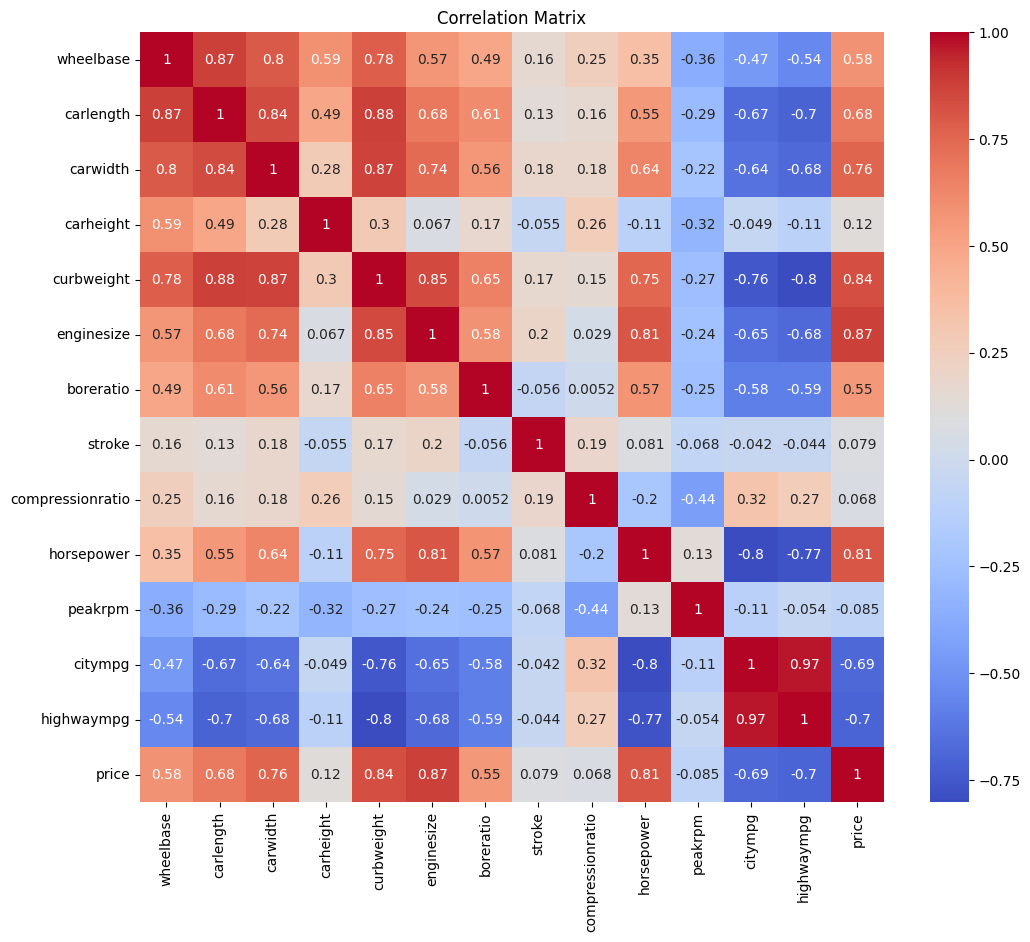

In [10]:
#Correlation Matrix
corr = car[num_col].corr()

plt.figure(figsize = (12,10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

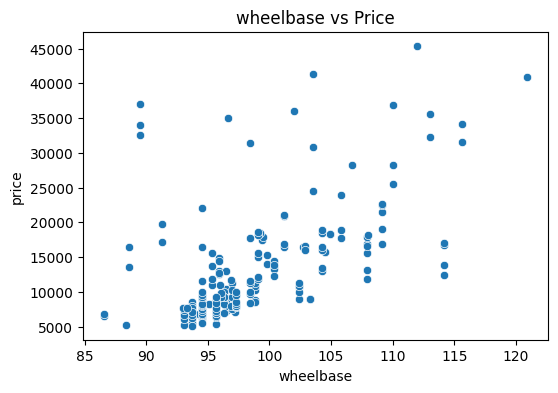

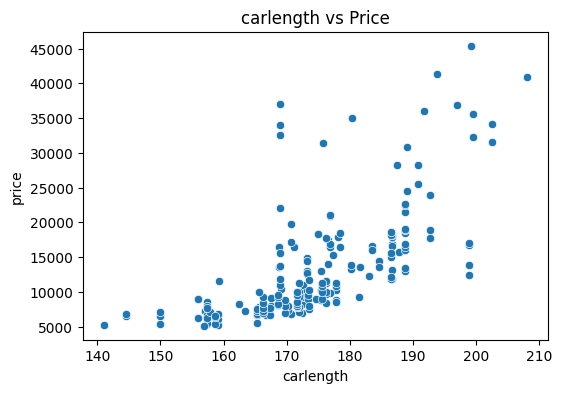

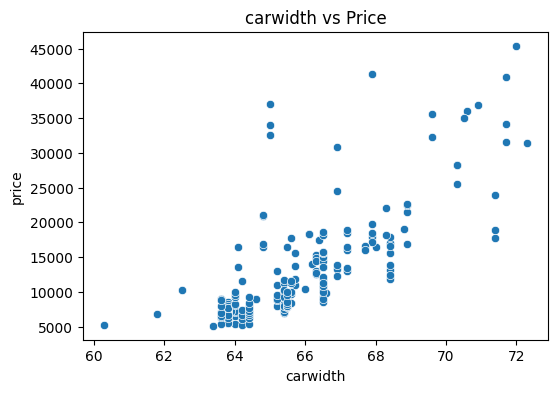

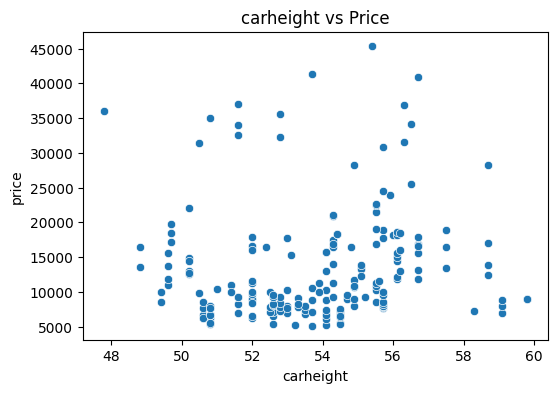

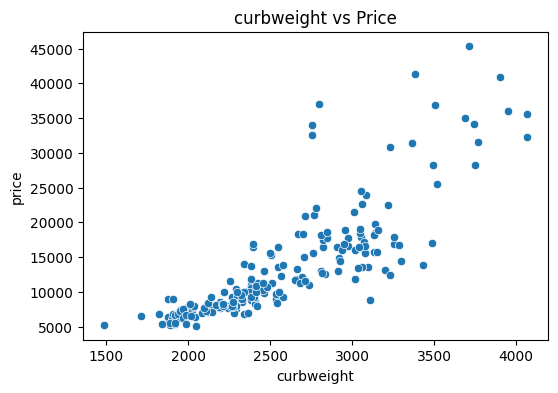

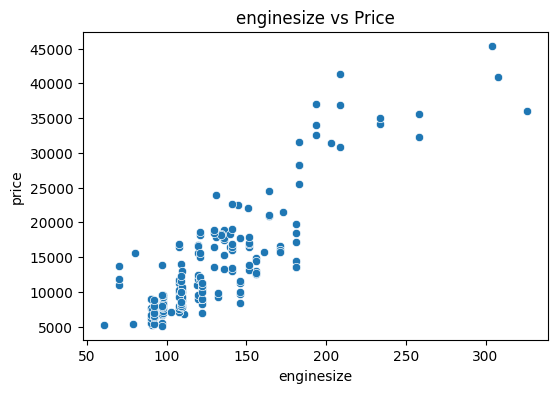

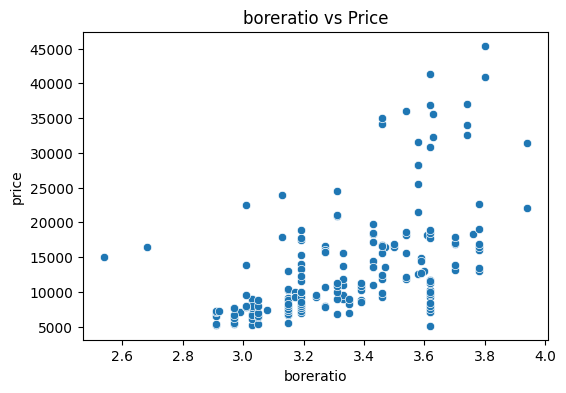

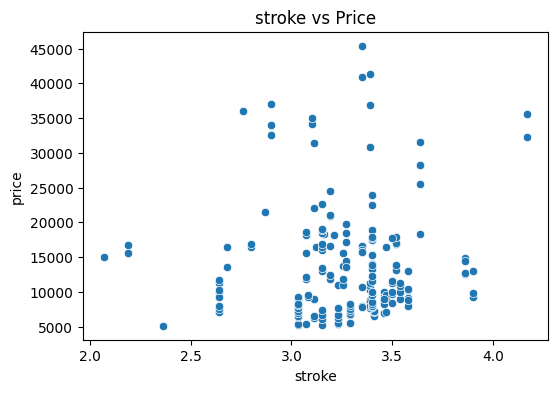

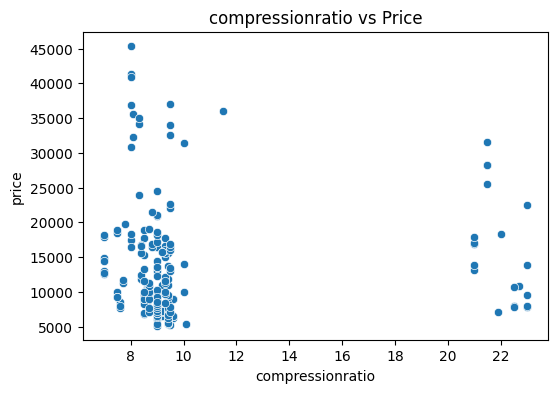

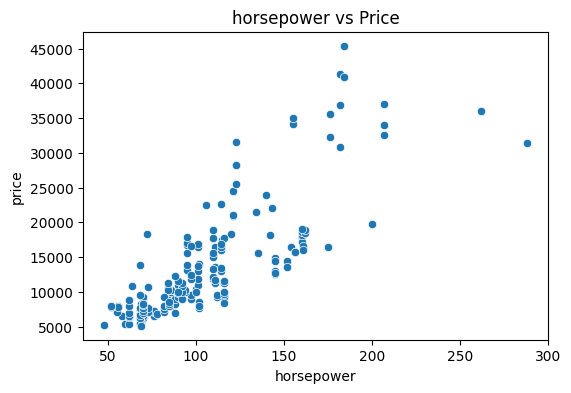

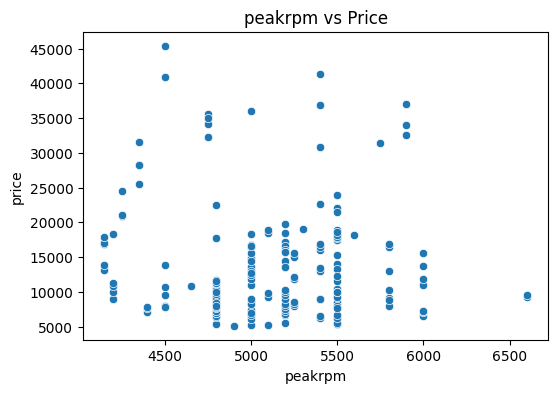

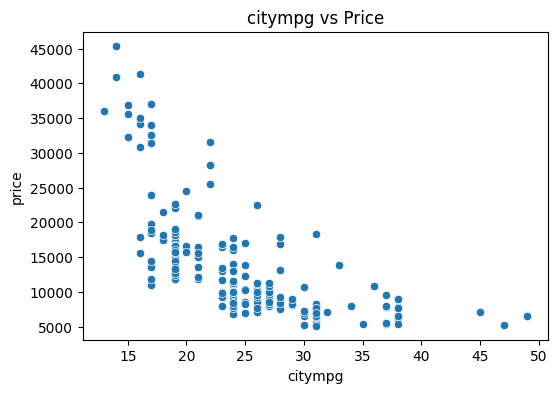

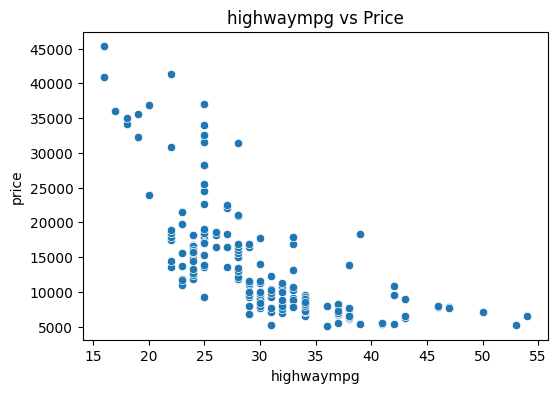

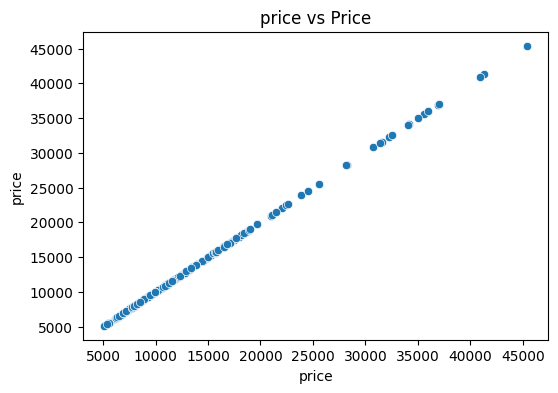

In [11]:
#Scatterplots (numerical column)
for feature in num_col:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=car[feature], y=car['price'])
    plt.title(f"{feature} vs Price")
    plt.show()

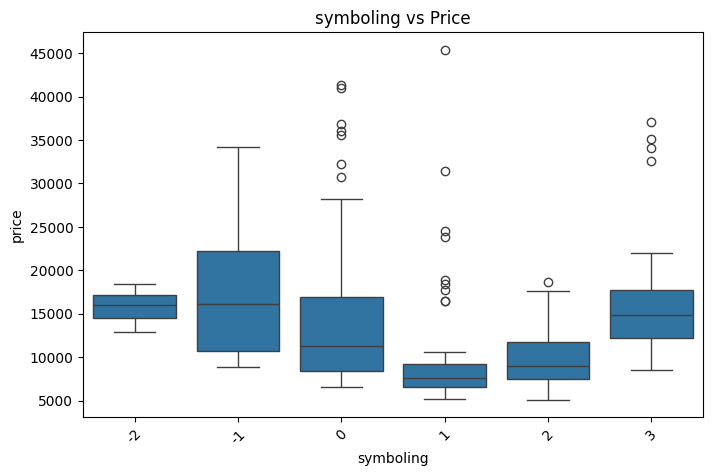

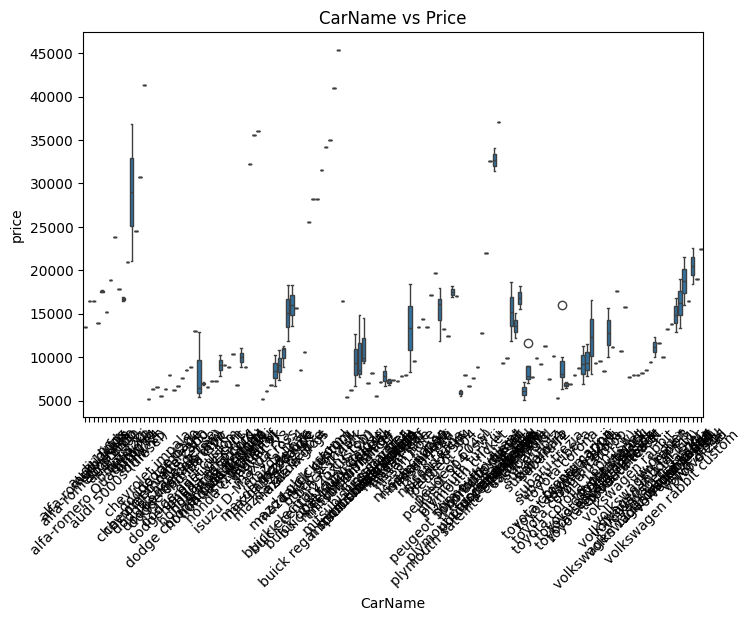

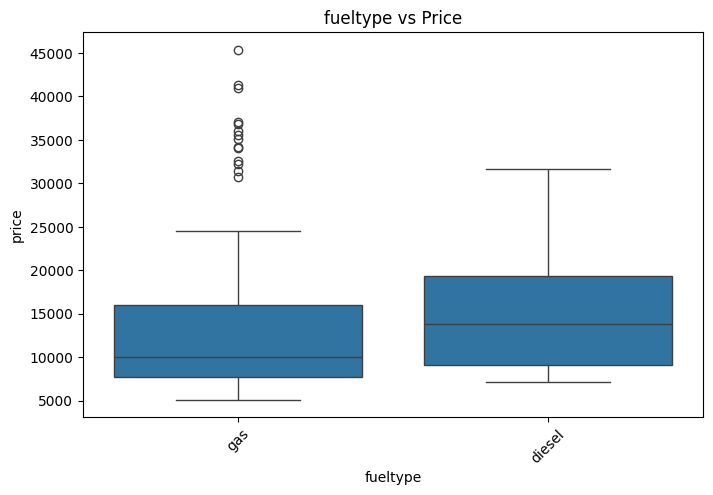

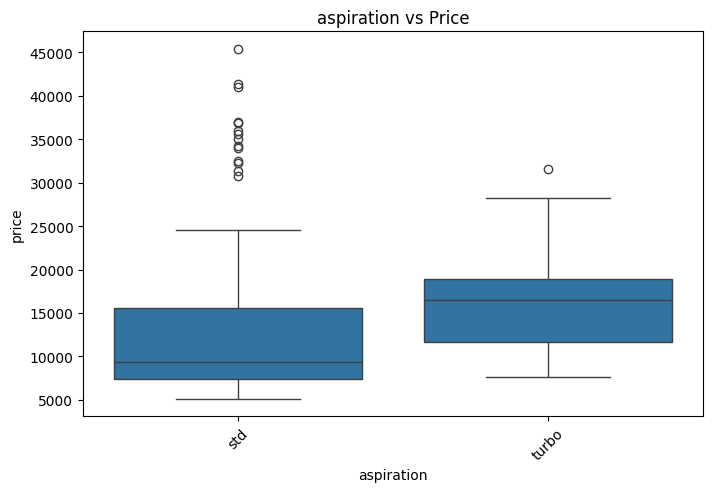

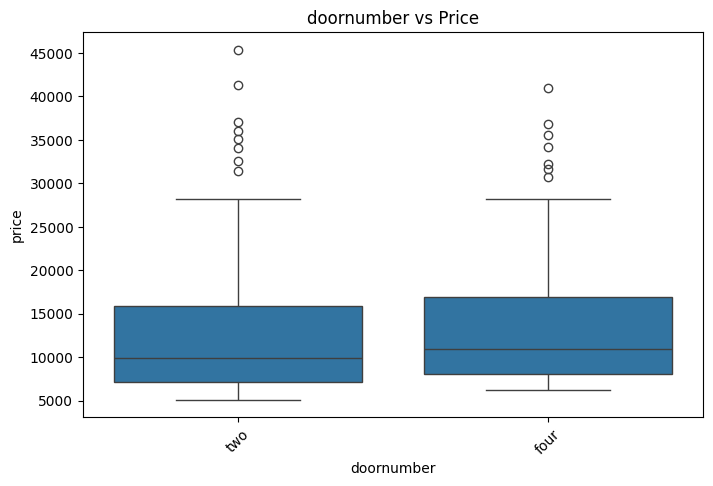

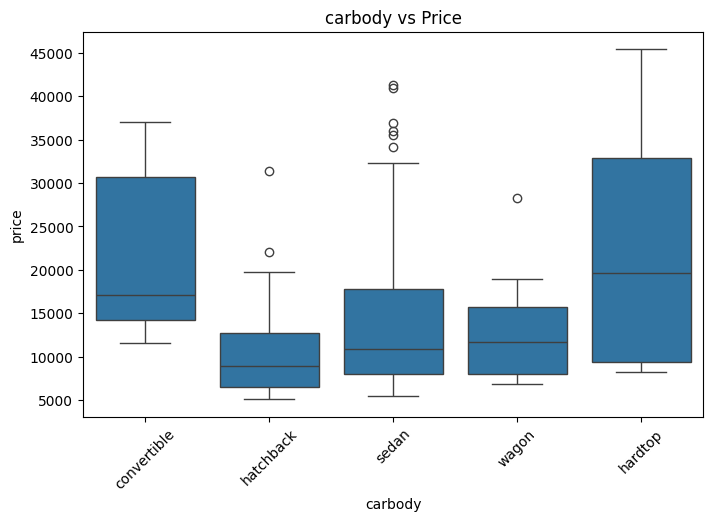

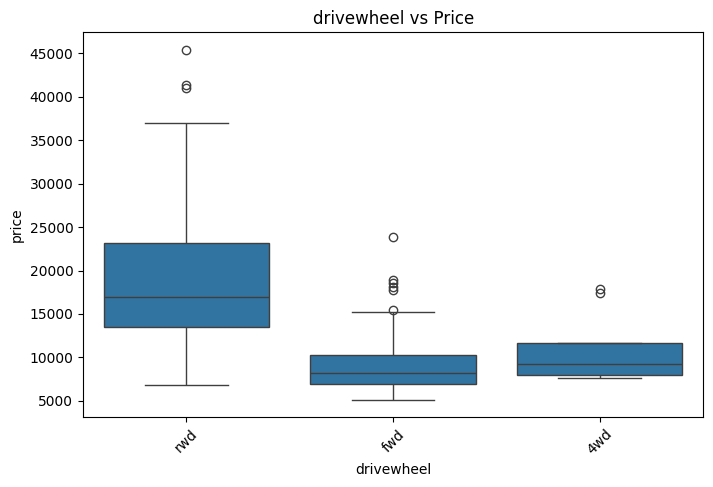

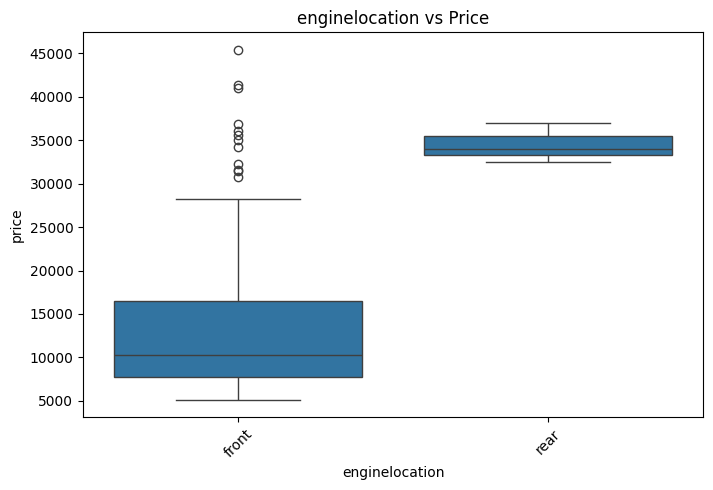

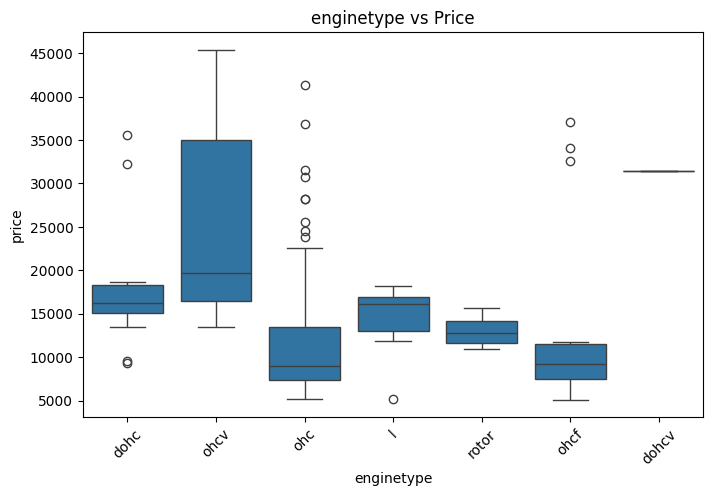

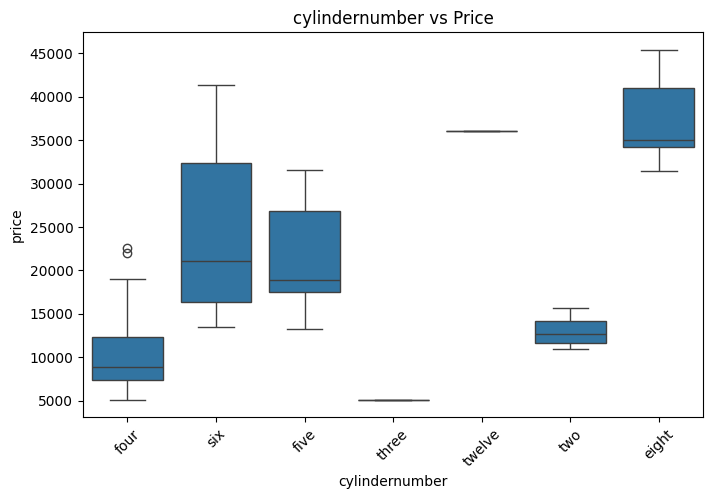

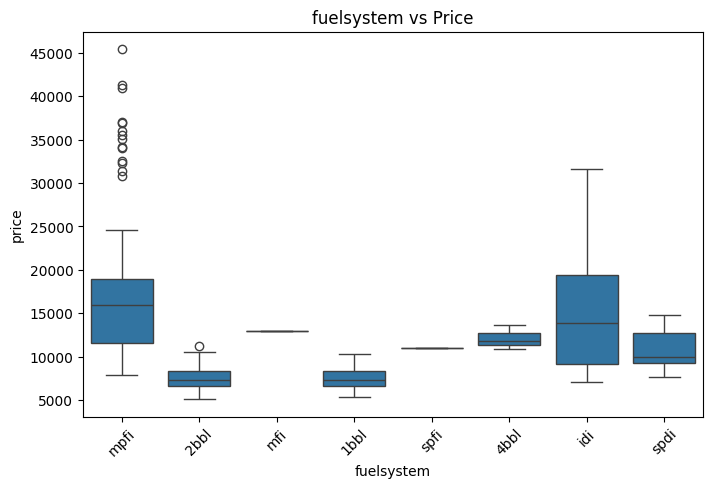

In [12]:
for feature in cat_col:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=car[feature], y=car['price'])
    plt.title(f"{feature} vs Price")
    plt.xticks(rotation=45)
    plt.show()

In [13]:
#Missing Value Check
car.isna().sum()

,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0
carlength,0


In [14]:
#Unique car names
car["CarName"].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

In [15]:
# create a function to fix the CarName column
def car_name_cleaner(car_name):
    return car_name.split(" ")[0].lower()

In [16]:
# apply the clean_car_name function to the CarName column
car["CarName"] = car["CarName"].apply(car_name_cleaner)

In [17]:
# see the unique values after fixing
car["CarName"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [18]:
# Fix typos
car["CarName"] = car["CarName"].str.replace('vw', 'volkswagen')
car["CarName"] = car["CarName"].str.replace('vokswagen', 'volkswagen')
car["CarName"] = car["CarName"].str.replace('toyouta', 'toyota')
car["CarName"] = car["CarName"].str.replace('maxda', 'mazda')
car["CarName"] = car["CarName"].str.replace('porcshce', 'porsche')


In [19]:
#Unique values after fix
car["CarName"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [20]:
#Define features and target
X = car.drop('price', axis = 1)
y = car["price"]

In [21]:
#Split into categorical and numeric columns
categorical_col = [
    'symboling',
    'CarName',
    'fueltype',
    'aspiration',
    'doornumber',
    'carbody',
    'drivewheel',
    'enginelocation',
    'enginetype',
    'cylindernumber',
    'fuelsystem'
]

number_col = [
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'boreratio',
    'stroke',
    'compressionratio',
    'horsepower',
    'peakrpm',
    'citympg',
    'highwaympg'
]

In [22]:
#Split into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [23]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), number_col),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_col)
    ]
)

In [24]:
#Apply preprocess

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [25]:
#Scale Target Variable

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [26]:
#Check shape of sets

print(f'Shape of X_train: {X_train_processed.shape}')
print(f'Shape of X_test: {X_test_processed.shape}')
print(f'Shape of y_train: {y_train_scaled.shape}')
print(f'Shape of y_test: {y_test_scaled.shape}')

Shape of X_train: (164, 67)
Shape of X_test: (41, 67)
Shape of y_train: (164, 1)
Shape of y_test: (41, 1)


In [27]:
#Intialize Linear model (baseline)
model = LinearRegression()

In [28]:
#Fit model
model.fit(X_train_processed, y_train)

LinearRegression()

In [29]:
#Predict price
y_pred = model.predict(X_test_processed)

In [31]:
#Evaluation metrics

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'\nModel Performance on Test Set:')
print(f'R-squared: {r2:.3f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (MSE): {np.sqrt(mse):.2f}')



Model Performance on Test Set:
R-squared: 0.902
Mean Absolute Error (MAE): 1911.30
Mean Absolute Percentage Error (MAPE): 1911.30
Mean Squared Error (MSE): 7741378.01
Root Mean Squared Error (MSE): 2782.33


In [39]:
#Neural Net Experimentation
#Experiment 1 - 

model1 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])


model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Train the neural net
patience=5
epochs=50
batch_size=32
history1 = model1.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.8938 - mae: 0.7756 - mape: 291.0222 - val_loss: 1.1092 - val_mae: 0.7891 - val_mape: 203.0581
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5255 - mae: 0.5726 - mape: 264.7974 - val_loss: 0.7642 - val_mae: 0.6250 - val_mape: 187.8892
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3350 - mae: 0.4302 - mape: 262.6224 - val_loss: 0.5878 - val_mae: 0.5385 - val_mape: 180.2029
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2499 - mae: 0.3802 - mape: 270.8077 - val_loss: 0.4843 - val_mae: 0.5077 - val_mape: 186.0170
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2216 - mae: 0.3803 - mape: 277.3381 - val_loss: 0.4382 - val_mae: 0.4902 - val_mape: 194.9701
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1896 - mae: 0.3577 - mape: 271.4277 - val_loss: 0.4053 - val_mae: 0.4617 - val_mape: 194.1553
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1615 - mae: 0.3246 - ma

In [41]:
train_pred_scaled = model1.predict(X_train_processed)
test_pred_scaled = model1.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [42]:
train_pred_1 = y_scaler.inverse_transform(train_pred_scaled).flatten()
test_pred_1 = y_scaler.inverse_transform(test_pred_scaled).flatten()

In [43]:
#Evaluation metrics on train and test set

train_mae_1 = mean_absolute_error(y_train, train_pred_1)
train_mse_1 = mean_squared_error(y_train, train_pred_1)
train_rmse_1 = np.sqrt(train_mse_1)
train_r2_1 = r2_score(y_train, train_pred_1)
train_mape_1 = mean_absolute_percentage_error(y_train, train_pred_1)

test_mae_1 = mean_absolute_error(y_test, test_pred_1)
test_mse_1 = mean_squared_error(y_test, test_pred_1)
test_rmse_1 = np.sqrt(test_mse_1)
test_r2_1 = r2_score(y_test, test_pred_1)
test_mape_1 = mean_absolute_percentage_error(y_test, test_pred_1)

In [44]:
print("Experiment 1: Single Layer - 64 Network")
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_1:.2f}")
print(f"MSE   : {train_mse_1:.2f}")
print(f"RMSE  : {train_rmse_1:.2f}")
print(f"R²    : {train_r2_1:.4f}")
print(f"MAPE  : {train_mape_1*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_1:.2f}")
print(f"MSE   : {test_mse_1:.2f}")
print(f"RMSE  : {test_rmse_1:.2f}")
print(f"R²    : {test_r2_1:.4f}")
print(f"MAPE  : {test_mape_1*100:.2f}%")

Experiment 1: Single Layer - 64 Network

TRAINING RESULTS
MAE   : 1076.82
MSE   : 2938591.38
RMSE  : 1714.23
R²    : 0.9507
MAPE  : 8.73%

TEST RESULTS
MAE   : 1815.73
MSE   : 6969631.71
RMSE  : 2640.01
R²    : 0.9117
MAPE  : 14.47%


In [45]:
#Neural Net Experimentation
#Experiment 2 - increased neurons - single layer 128, 64

model2 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1)
])


model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
patience=5
epochs=50
batch_size=32
history2 = model2.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.8313 - mae: 0.5537 - mape: 201.6319 - val_loss: 1.1056 - val_mae: 0.6165 - val_mape: 83.0424
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4444 - mae: 0.3916 - mape: 96.7500 - val_loss: 0.6364 - val_mae: 0.4904 - val_mape: 78.2581
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3316 - mae: 0.3549 - mape: 215.8937 - val_loss: 0.3909 - val_mae: 0.4247 - val_mape: 99.8342
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2624 - mae: 0.3523 - mape: 242.0603 - val_loss: 0.2946 - val_mae: 0.4013 - val_mape: 120.1606
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2245 - mae: 0.3416 - mape: 255.0297 - val_loss: 0.2624 - val_mae: 0.3812 - val_mape: 118.5067
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1752 - mae: 0.3012 - mape: 222.6699 - val_loss: 0.2482 - val_mae: 0.3566 - val_mape: 109.5153
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1368 - mae: 0.2598 - mape: 

In [47]:
train_pred_scaled_2 = model2.predict(X_train_processed)
test_pred_scaled_2 = model2.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [48]:
train_pred_2 = y_scaler.inverse_transform(train_pred_scaled_2).flatten()
test_pred_2 = y_scaler.inverse_transform(test_pred_scaled_2).flatten()

In [49]:
train_mae_2 = mean_absolute_error(y_train, train_pred_2)
train_mse_2 = mean_squared_error(y_train, train_pred_2)
train_rmse_2 = np.sqrt(train_mse_2)
train_r2_2 = r2_score(y_train, train_pred_2)
train_mape_2 = mean_absolute_percentage_error(y_train, train_pred_2)

test_mae_2 = mean_absolute_error(y_test, test_pred_2)
test_mse_2 = mean_squared_error(y_test, test_pred_2)
test_rmse_2 = np.sqrt(test_mse_2)
test_r2_2 = r2_score(y_test, test_pred_2)
test_mape_2 = mean_absolute_percentage_error(y_test, test_pred_2)

In [50]:
print("Experiment 2: 128-64 Network")
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_2:.2f}")
print(f"MSE   : {train_mse_2:.2f}")
print(f"RMSE  : {train_rmse_2:.2f}")
print(f"R²    : {train_r2_2:.4f}")
print(f"MAPE  : {train_mape_2*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_2:.2f}")
print(f"MSE   : {test_mse_2:.2f}")
print(f"RMSE  : {test_rmse_2:.2f}")
print(f"R²    : {test_r2_2:.4f}")
print(f"MAPE  : {test_mape_2*100:.2f}%")

Experiment 2: 128-64 Network

TRAINING RESULTS
MAE   : 944.44
MSE   : 1947459.45
RMSE  : 1395.51
R²    : 0.9673
MAPE  : 7.35%

TEST RESULTS
MAE   : 1537.68
MSE   : 5495516.97
RMSE  : 2344.25
R²    : 0.9304
MAPE  : 11.74%


In [51]:
model3 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])


model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
patience=5
epochs=50
batch_size=32
history3 = model3.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.8479 - mae: 0.7446 - mape: 191.5618 - val_loss: 0.6368 - val_mae: 0.5257 - val_mape: 115.3926
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2904 - mae: 0.3749 - mape: 269.7565 - val_loss: 0.2952 - val_mae: 0.4483 - val_mape: 165.9396
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1978 - mae: 0.3421 - mape: 353.1909 - val_loss: 0.2441 - val_mae: 0.4236 - val_mape: 186.1327
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1639 - mae: 0.3095 - mape: 344.4347 - val_loss: 0.1882 - val_mae: 0.3586 - val_mape: 170.2178
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1025 - mae: 0.2400 - mape: 264.4169 - val_loss: 0.1609 - val_mae: 0.2926 - val_mape: 151.3067
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0825 - mae: 0.2189 - mape: 236.1614 - val_loss: 0.1636 - val_mae: 0.2851 - val_mape: 132.9526
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0686 - mae: 0.1981 - ma

In [53]:
train_pred_scaled_3 = model3.predict(X_train_processed)
test_pred_scaled_3 = model3.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [54]:
train_pred_3 = y_scaler.inverse_transform(train_pred_scaled_3).flatten()
test_pred_3 = y_scaler.inverse_transform(test_pred_scaled_3).flatten()

In [55]:
train_mae_3 = mean_absolute_error(y_train, train_pred_3)
train_mse_3 = mean_squared_error(y_train, train_pred_3)
train_rmse_3 = np.sqrt(train_mse_3)
train_r2_3 = r2_score(y_train, train_pred_3)
train_mape_3 = mean_absolute_percentage_error(y_train, train_pred_3)

test_mae_3 = mean_absolute_error(y_test, test_pred_3)
test_mse_3 = mean_squared_error(y_test, test_pred_3)
test_rmse_3 = np.sqrt(test_mse_3)
test_r2_3 = r2_score(y_test, test_pred_3)
test_mape_3 = mean_absolute_percentage_error(y_test, test_pred_3)

In [56]:
print("Experiment 3: 128-64 Network")
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_3:.2f}")
print(f"MSE   : {train_mse_3:.2f}")
print(f"RMSE  : {train_rmse_3:.2f}")
print(f"R²    : {train_r2_3:.4f}")
print(f"MAPE  : {train_mape_3*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_3:.2f}")
print(f"MSE   : {test_mse_3:.2f}")
print(f"RMSE  : {test_rmse_3:.2f}")
print(f"R²    : {test_r2_3:.4f}")
print(f"MAPE  : {test_mape_3*100:.2f}%")

Experiment 3: 128-64 Network

TRAINING RESULTS
MAE   : 1036.39
MSE   : 2235746.34
RMSE  : 1495.24
R²    : 0.9625
MAPE  : 8.39%

TEST RESULTS
MAE   : 1744.30
MSE   : 6996280.08
RMSE  : 2645.05
R²    : 0.9114
MAPE  : 15.72%


In [57]:
model4 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1)
])


model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
patience=5
epochs=50
batch_size=32
history4 = model4.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 1.0232 - mae: 0.6395 - mape: 211.8108 - val_loss: 1.2843 - val_mae: 0.6838 - val_mape: 94.3586
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6034 - mae: 0.4657 - mape: 135.4618 - val_loss: 0.7895 - val_mae: 0.5280 - val_mape: 94.0736
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4189 - mae: 0.4101 - mape: 255.8805 - val_loss: 0.5633 - val_mae: 0.4917 - val_mape: 125.5525
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3394 - mae: 0.3940 - mape: 301.1521 - val_loss: 0.4612 - val_mae: 0.4626 - val_mape: 139.7194
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2571 - mae: 0.3421 - mape: 275.1521 - val_loss: 0.4028 - val_mae: 0.4149 - val_mape: 137.9914
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2031 - mae: 0.2965 - mape: 215.9516 - val_loss: 0.3710 - val_mae: 0.3841 - val_mape: 123.3889
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1655 - mae: 0.2594 - mape

In [59]:
train_pred_scaled_4 = model4.predict(X_train_processed)
test_pred_scaled_4 = model4.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [60]:
train_pred_4 = y_scaler.inverse_transform(train_pred_scaled_4).flatten()
test_pred_4 = y_scaler.inverse_transform(test_pred_scaled_4).flatten()

In [61]:
train_mae_4 = mean_absolute_error(y_train, train_pred_4)
train_mse_4 = mean_squared_error(y_train, train_pred_4)
train_rmse_4 = np.sqrt(train_mse_4)
train_r2_4 = r2_score(y_train, train_pred_4)
train_mape_4 = mean_absolute_percentage_error(y_train, train_pred_4)

test_mae_4 = mean_absolute_error(y_test, test_pred_4)
test_mse_4 = mean_squared_error(y_test, test_pred_4)
test_rmse_4 = np.sqrt(test_mse_4)
test_r2_4 = r2_score(y_test, test_pred_4)
test_mape_4 = mean_absolute_percentage_error(y_test, test_pred_4)

In [62]:
print("Experiment 4: 128-64 Network")
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_4:.2f}")
print(f"MSE   : {train_mse_4:.2f}")
print(f"RMSE  : {train_rmse_4:.2f}")
print(f"R²    : {train_r2_4:.4f}")
print(f"MAPE  : {train_mape_4*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_4:.2f}")
print(f"MSE   : {test_mse_4:.2f}")
print(f"RMSE  : {test_rmse_4:.2f}")
print(f"R²    : {test_r2_4:.4f}")
print(f"MAPE  : {test_mape_4*100:.2f}%")

Experiment 4: 128-64 Network

TRAINING RESULTS
MAE   : 1026.38
MSE   : 2848508.13
RMSE  : 1687.75
R²    : 0.9522
MAPE  : 7.91%

TEST RESULTS
MAE   : 1562.15
MSE   : 6592307.73
RMSE  : 2567.55
R²    : 0.9165
MAPE  : 12.91%


In [63]:
model5 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(256, activation='relu'),
    Dense(1)
])


model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
patience=5
epochs=50
batch_size=32
history5 = model5.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.6411 - mae: 0.5250 - mape: 175.7074 - val_loss: 0.4735 - val_mae: 0.4051 - val_mape: 68.8820
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2698 - mae: 0.3375 - mape: 195.0317 - val_loss: 0.2754 - val_mae: 0.4128 - val_mape: 133.2908
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1859 - mae: 0.3250 - mape: 224.6193 - val_loss: 0.2324 - val_mae: 0.3823 - val_mape: 166.1504
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1302 - mae: 0.2735 - mape: 207.4613 - val_loss: 0.2033 - val_mae: 0.3335 - val_mape: 144.7726
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0910 - mae: 0.2230 - mape: 178.5702 - val_loss: 0.1859 - val_mae: 0.2998 - val_mape: 129.3275
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0756 - mae: 0.2067 - mape: 169.8771 - val_loss: 0.1840 - val_mae: 0.2950 - val_mape: 131.3828
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0739 - mae: 0.2036 - map

In [65]:
train_pred_scaled_5 = model5.predict(X_train_processed)
test_pred_scaled_5 = model5.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [66]:
train_pred_5 = y_scaler.inverse_transform(train_pred_scaled_5).flatten()
test_pred_5 = y_scaler.inverse_transform(test_pred_scaled_5).flatten()

In [67]:
train_mae_5 = mean_absolute_error(y_train, train_pred_5)
train_mse_5 = mean_squared_error(y_train, train_pred_5)
train_rmse_5 = np.sqrt(train_mse_5)
train_r2_5 = r2_score(y_train, train_pred_5)
train_mape_5 = mean_absolute_percentage_error(y_train, train_pred_5)

test_mae_5 = mean_absolute_error(y_test, test_pred_5)
test_mse_5 = mean_squared_error(y_test, test_pred_5)
test_rmse_5 = np.sqrt(test_mse_5)
test_r2_5 = r2_score(y_test, test_pred_5)
test_mape_5 = mean_absolute_percentage_error(y_test, test_pred_5)

In [68]:
print("Experiment 5: 128-64 Network")
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_5:.2f}")
print(f"MSE   : {train_mse_5:.2f}")
print(f"RMSE  : {train_rmse_5:.2f}")
print(f"R²    : {train_r2_5:.4f}")
print(f"MAPE  : {train_mape_5*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_5:.2f}")
print(f"MSE   : {test_mse_5:.2f}")
print(f"RMSE  : {test_rmse_5:.2f}")
print(f"R²    : {test_r2_5:.4f}")
print(f"MAPE  : {test_mape_5*100:.2f}%")

Experiment 5: 128-64 Network

TRAINING RESULTS
MAE   : 900.80
MSE   : 1919246.04
RMSE  : 1385.37
R²    : 0.9678
MAPE  : 7.23%

TEST RESULTS
MAE   : 1722.30
MSE   : 5925269.44
RMSE  : 2434.19
R²    : 0.9249
MAPE  : 14.49%


In [69]:
model6 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1)
])


model6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae', 'mape']
)
model6.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
patience=5
epochs=50
batch_size=32
history6 = model6.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.7259 - mae: 0.7077 - mape: 275.4825 - val_loss: 0.8535 - val_mae: 0.7227 - val_mape: 183.2750
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4952 - mae: 0.5656 - mape: 263.1852 - val_loss: 0.6197 - val_mae: 0.6029 - val_mape: 182.5611
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3498 - mae: 0.4541 - mape: 256.5199 - val_loss: 0.4815 - val_mae: 0.5019 - val_mape: 179.4371
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2702 - mae: 0.3853 - mape: 248.4886 - val_loss: 0.4054 - val_mae: 0.4268 - val_mape: 174.4606
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2219 - mae: 0.3493 - mape: 240.3746 - val_loss: 0.3608 - val_mae: 0.3999 - val_mape: 172.3114
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1938 - mae: 0.3368 - mape: 236.0855 - val_loss: 0.3272 - val_mae: 0.3863 - val_mape: 170.8435
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1685 - mae: 0.3170 - m

In [71]:
train_pred_scaled_6 = model6.predict(X_train_processed)
test_pred_scaled_6 = model6.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [72]:
train_pred_6 = y_scaler.inverse_transform(train_pred_scaled_6).flatten()
test_pred_6 = y_scaler.inverse_transform(test_pred_scaled_6).flatten()

In [73]:
train_mae_6 = mean_absolute_error(y_train, train_pred_6)
train_mse_6 = mean_squared_error(y_train, train_pred_6)
train_rmse_6 = np.sqrt(train_mse_6)
train_r2_6 = r2_score(y_train, train_pred_6)
train_mape_6 = mean_absolute_percentage_error(y_train, train_pred_6)

test_mae_6 = mean_absolute_error(y_test, test_pred_6)
test_mse_6 = mean_squared_error(y_test, test_pred_6)
test_rmse_6 = np.sqrt(test_mse_6)
test_r2_6 = r2_score(y_test, test_pred_6)
test_mape_6 = mean_absolute_percentage_error(y_test, test_pred_6)

In [74]:
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_6:.2f}")
print(f"MSE   : {train_mse_6:.2f}")
print(f"RMSE  : {train_rmse_6:.2f}")
print(f"R²    : {train_r2_6:.4f}")
print(f"MAPE  : {train_mape_6*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_6:.2f}")
print(f"MSE   : {test_mse_6:.2f}")
print(f"RMSE  : {test_rmse_6:.2f}")
print(f"R²    : {test_r2_6:.4f}")
print(f"MAPE  : {test_mape_6*100:.2f}%")


TRAINING RESULTS
MAE   : 1200.17
MSE   : 3218534.98
RMSE  : 1794.03
R²    : 0.9460
MAPE  : 9.37%

TEST RESULTS
MAE   : 1933.26
MSE   : 7764528.75
RMSE  : 2786.49
R²    : 0.9016
MAPE  : 15.41%


In [81]:
model7 = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1)
])


model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model7.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
patience=5
epochs=50
batch_size=32
history7 = model7.fit(
    X_train_processed, y_train_scaled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.9920 - mae: 0.7830 - mape: 372.1239 - val_loss: 0.9567 - val_mae: 0.7228 - val_mape: 154.8420
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5269 - mae: 0.5184 - mape: 170.8253 - val_loss: 0.5118 - val_mae: 0.4887 - val_mape: 142.3879
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3129 - mae: 0.3844 - mape: 203.6506 - val_loss: 0.3632 - val_mae: 0.4518 - val_mape: 160.8788
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2253 - mae: 0.3749 - mape: 141.4925 - val_loss: 0.3277 - val_mae: 0.4436 - val_mape: 169.7123
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2445 - mae: 0.3822 - mape: 180.2653 - val_loss: 0.3047 - val_mae: 0.4163 - val_mape: 160.6519
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1734 - mae: 0.3201 - mape: 134.8788 - val_loss: 0.2960 - val_mae: 0.3886 - val_mape: 151.8057
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1616 - mae: 0.3004 - ma

In [83]:
train_pred_scaled_7 = model7.predict(X_train_processed)
test_pred_scaled_7 = model7.predict(X_test_processed)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [84]:
train_pred_7 = y_scaler.inverse_transform(train_pred_scaled_7).flatten()
test_pred_7 = y_scaler.inverse_transform(test_pred_scaled_7).flatten()

In [85]:
train_mae_7 = mean_absolute_error(y_train, train_pred_7)
train_mse_7 = mean_squared_error(y_train, train_pred_7)
train_rmse_7 = np.sqrt(train_mse_7)
train_r2_7 = r2_score(y_train, train_pred_7)
train_mape_7 = mean_absolute_percentage_error(y_train, train_pred_7)

test_mae_7 = mean_absolute_error(y_test, test_pred_7)
test_mse_7 = mean_squared_error(y_test, test_pred_7)
test_rmse_7 = np.sqrt(test_mse_7)
test_r2_7 = r2_score(y_test, test_pred_7)
test_mape_7 = mean_absolute_percentage_error(y_test, test_pred_7)

In [86]:
print("\nTRAINING RESULTS")
print(f"MAE   : {train_mae_7:.2f}")
print(f"MSE   : {train_mse_7:.2f}")
print(f"RMSE  : {train_rmse_7:.2f}")
print(f"R²    : {train_r2_7:.4f}")
print(f"MAPE  : {train_mape_7*100:.2f}%")

print("\nTEST RESULTS")
print(f"MAE   : {test_mae_7:.2f}")
print(f"MSE   : {test_mse_7:.2f}")
print(f"RMSE  : {test_rmse_7:.2f}")
print(f"R²    : {test_r2_7:.4f}")
print(f"MAPE  : {test_mape_7*100:.2f}%")


TRAINING RESULTS
MAE   : 1267.80
MSE   : 3770639.82
RMSE  : 1941.81
R²    : 0.9368
MAPE  : 10.22%

TEST RESULTS
MAE   : 2381.58
MSE   : 9696440.68
RMSE  : 3113.91
R²    : 0.8772
MAPE  : 21.07%


| Experiment | Architecture | Test R² | Test RMSE | Test MAE | Test MAPE |
|------------|-------------|------------|-----------|-----------|-----------|
| Baseline | Linear Regression | 0.90 | $2782 | $1911 | 18.72% |
| Experiment 1 | 64 - Single Layer | 0.91 | $2640 | $1815 | 14.47% |
| Experiment 2 | 128 - Single Layer | 0.94 | $2148 | $1377 | 10.43% |
| Experiment 3 | 128, 64 - Two Layer | 0.91 | $2645 | $1744 | 15.72% |
| Experiment 4 | 64, 128 - Two Layer | 0.92 | $2568 | $1562 | 12.91% |
| Experiment 5 | 256 - Single Layer | 0.92 | $2434 | $1722 | 14.49% |
| Experiment 6 | 128 - Single Layer (Slower LR) | 0.90 | $2786 | $1933 | 15.41% |
| Experiment 7 | 128 - Single Layer (Dropout) | 0.88 | $3113 | $2381 | 21.07% |
